# Cold-Start Energy Prediction — Exploratory Data Analysis

This notebook explores the CEEW Smart Meter dataset from Mathura, India.

**Objectives:**
- Understand the data structure and distributions
- Visualize energy consumption patterns over time
- Analyze temporal trends (hourly, daily, monthly)
- Examine the distribution shift between 2019 and 2020
- Explore feature correlations

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings

warnings.filterwarnings('ignore')

# Use a clean style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['figure.dpi'] = 120

## 1. Load the Data

In [2]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

from config import DATA_2019_PATH, DATA_2020_PATH, TARGET
from src.data_loader import load_data

df_2019 = load_data(DATA_2019_PATH)
df_2020 = load_data(DATA_2020_PATH)

print(f'2019: {df_2019.shape[0]} hourly records, {df_2019.shape[1]} columns')
print(f'2020: {df_2020.shape[0]} hourly records, {df_2020.shape[1]} columns')

2019: 5880 hourly records, 4 columns
2020: 8328 hourly records, 4 columns


In [3]:
df_2019.head(10)

,t_kWh,z_Avg Voltage (Volt),z_Avg Current (Amp),y_Freq (Hz)
x_Timestamp,,,,
2019-05-01 00:00:00,0.054185,214.87805,5.27855,50.01380
2019-05-01 01:00:00,0.054155,217.67660,5.22880,50.04575
2019-05-01 02:00:00,0.046655,221.06420,4.56620,50.08355
2019-05-01 03:00:00,0.047030,228.99790,4.43215,50.04165
2019-05-01 04:00:00,0.045695,235.49705,4.13720,50.03705
2019-05-01 05:00:00,0.041545,238.18100,3.76260,50.03935
2019-05-01 06:00:00,0.030505,247.67850,2.80230,50.05245
2019-05-01 07:00:00,0.023315,239.93460,2.24585,49.59540
2019-05-01 08:00:00,0.015765,233.50140,1.62625,48.65695


## 2. Descriptive Statistics

In [4]:
print('=== 2019 ===')
display(df_2019.describe())
print()
print('=== 2020 ===')
display(df_2020.describe())

=== 2019 ===


,t_kWh,z_Avg Voltage (Volt),z_Avg Current (Amp),y_Freq (Hz)
count,5880.000000,5880.000000,5880.000000,5880.000000
mean,0.022269,227.173443,2.173633,47.615197
std,0.013833,26.183088,1.290555,4.739998
min,0.000000,0.000000,0.000000,0.000000
25%,0.011128,216.800807,1.116244,47.472381
50%,0.019258,231.758150,1.936114,49.743377
75%,0.031507,244.142501,2.990625,50.010500
max,0.067850,283.482333,6.328682,50.258750



=== 2020 ===


,t_kWh,z_Avg Voltage (Volt),z_Avg Current (Amp),y_Freq (Hz)
count,8328.000000,8328.000000,8328.000000,8328.000000
mean,0.008741,224.919254,0.892655,45.049426
std,0.008363,22.449995,0.764629,4.073660
min,0.000673,10.056258,0.080419,2.017903
25%,0.003914,214.007058,0.438887,43.078872
50%,0.004468,228.876736,0.508523,45.833773
75%,0.010211,240.966349,1.022842,48.008141
max,0.047369,261.548333,4.696947,50.220842


## 3. Energy Consumption Over Time

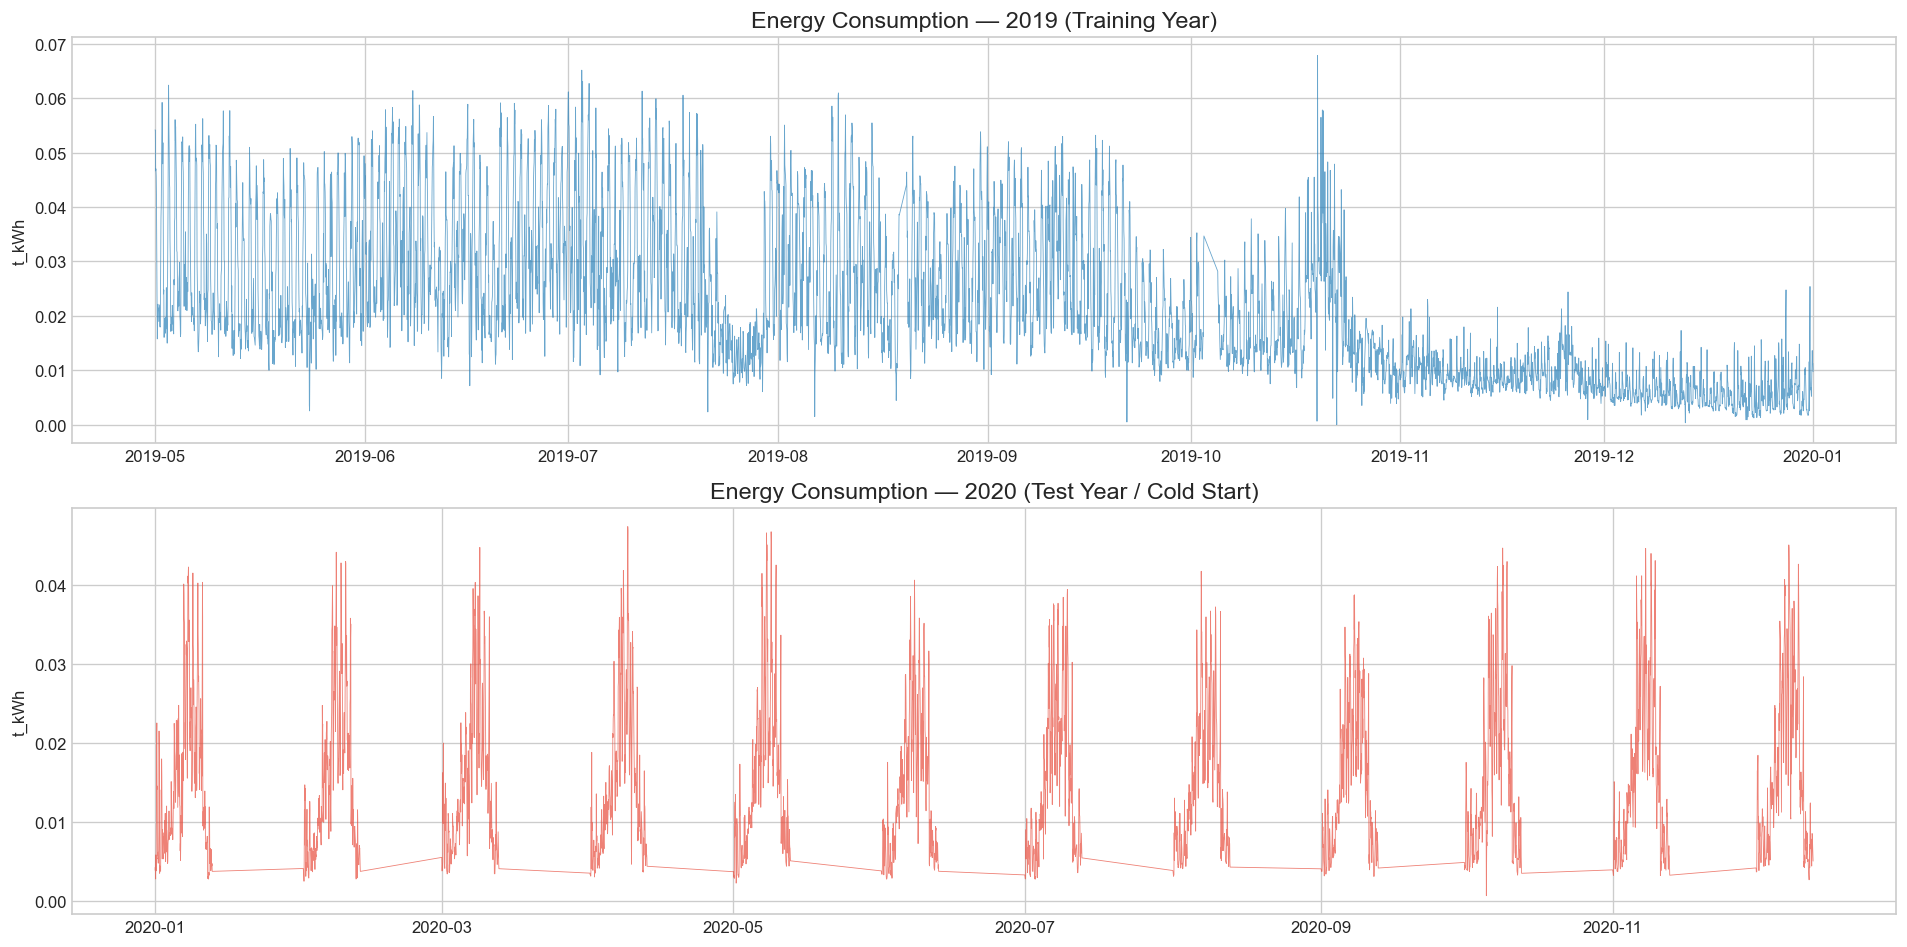

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=False)

axes[0].plot(df_2019.index, df_2019[TARGET], color='#2980b9', linewidth=0.5, alpha=0.7)
axes[0].set_title('Energy Consumption — 2019 (Training Year)', fontsize=14)
axes[0].set_ylabel('t_kWh')

axes[1].plot(df_2020.index, df_2020[TARGET], color='#e74c3c', linewidth=0.5, alpha=0.7)
axes[1].set_title('Energy Consumption — 2020 (Test Year / Cold Start)', fontsize=14)
axes[1].set_ylabel('t_kWh')

plt.tight_layout()
plt.show()

## 4. Distribution Comparison (2019 vs 2020)

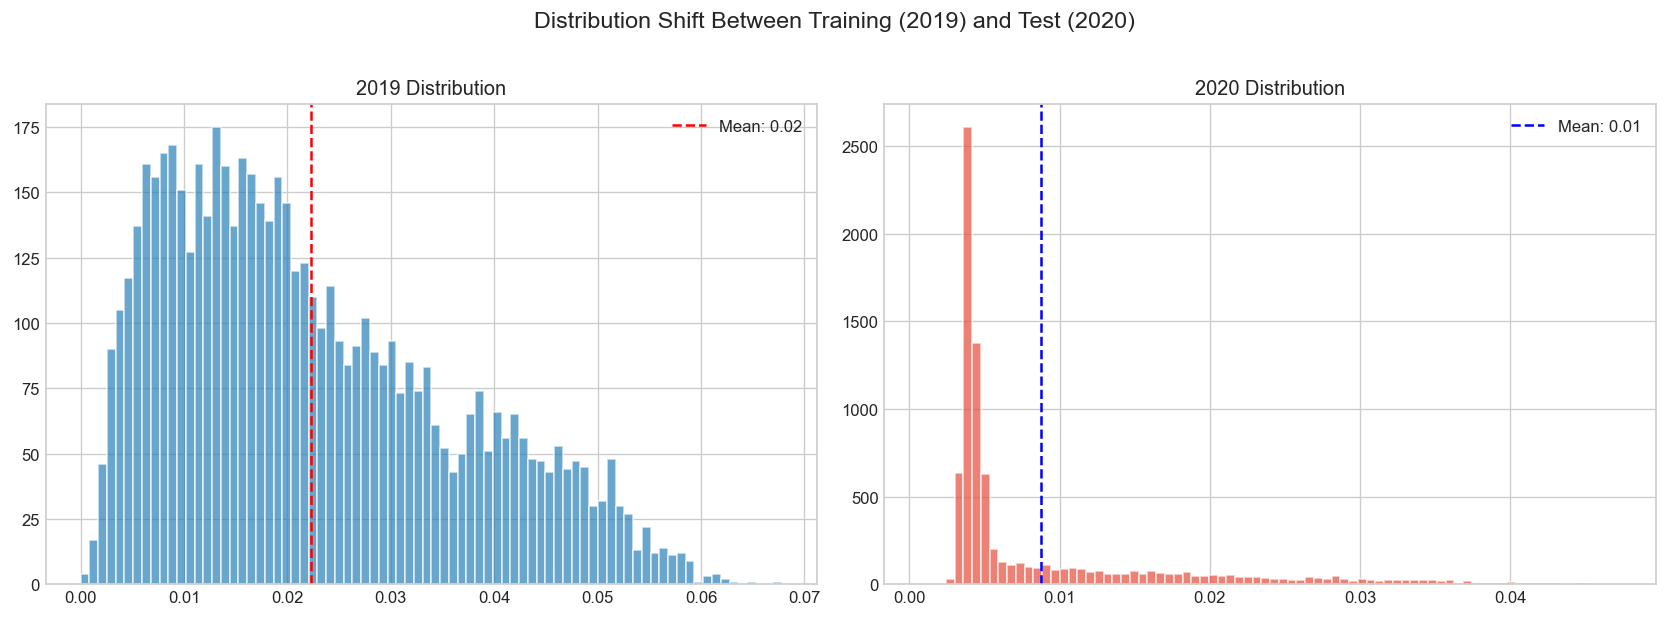

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_2019[TARGET], bins=80, color='#2980b9', alpha=0.7, edgecolor='white')
axes[0].axvline(df_2019[TARGET].mean(), color='red', linestyle='--', label=f'Mean: {df_2019[TARGET].mean():.2f}')
axes[0].set_title('2019 Distribution')
axes[0].legend()

axes[1].hist(df_2020[TARGET], bins=80, color='#e74c3c', alpha=0.7, edgecolor='white')
axes[1].axvline(df_2020[TARGET].mean(), color='blue', linestyle='--', label=f'Mean: {df_2020[TARGET].mean():.2f}')
axes[1].set_title('2020 Distribution')
axes[1].legend()

plt.suptitle('Distribution Shift Between Training (2019) and Test (2020)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 5. Hourly Consumption Patterns

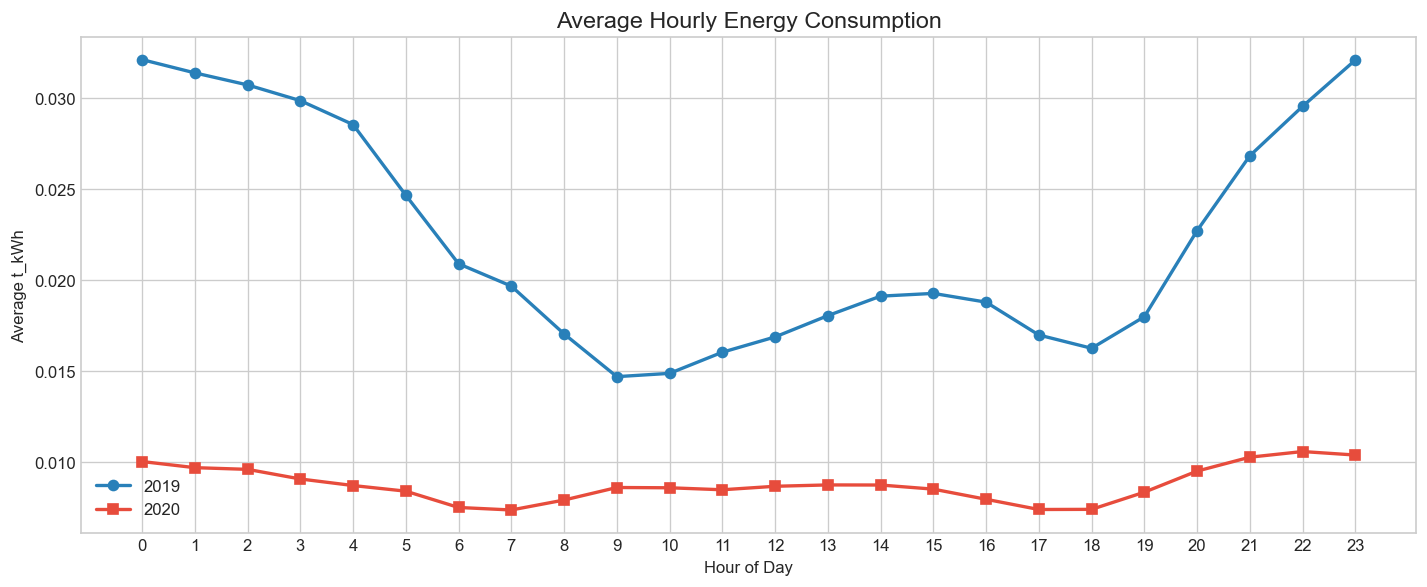

In [7]:
hourly_2019 = df_2019.groupby(df_2019.index.hour)[TARGET].mean()
hourly_2020 = df_2020.groupby(df_2020.index.hour)[TARGET].mean()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(hourly_2019.index, hourly_2019.values, 'o-', color='#2980b9', label='2019', linewidth=2)
ax.plot(hourly_2020.index, hourly_2020.values, 's-', color='#e74c3c', label='2020', linewidth=2)
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Average t_kWh')
ax.set_title('Average Hourly Energy Consumption', fontsize=14)
ax.set_xticks(range(24))
ax.legend()
plt.tight_layout()
plt.show()

## 6. Monthly Trends

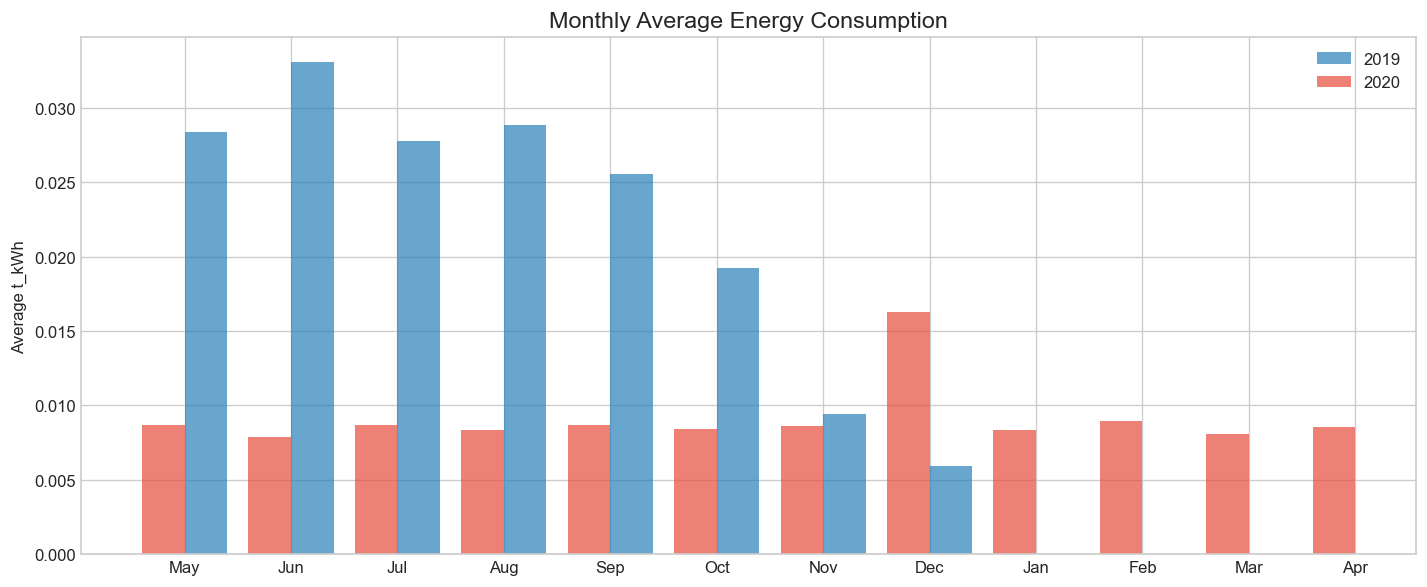

In [8]:
monthly_2019 = df_2019.resample('M')[TARGET].mean()
monthly_2020 = df_2020.resample('M')[TARGET].mean()

fig, ax = plt.subplots(figsize=(12, 5))

ax.bar(monthly_2019.index.strftime('%b'), monthly_2019.values, color='#2980b9', alpha=0.7, label='2019', width=0.4, align='edge')
ax.bar(monthly_2020.index.strftime('%b'), monthly_2020.values, color='#e74c3c', alpha=0.7, label='2020', width=-0.4, align='edge')
ax.set_ylabel('Average t_kWh')
ax.set_title('Monthly Average Energy Consumption', fontsize=14)
ax.legend()
plt.tight_layout()
plt.show()

## 7. Correlation Heatmap

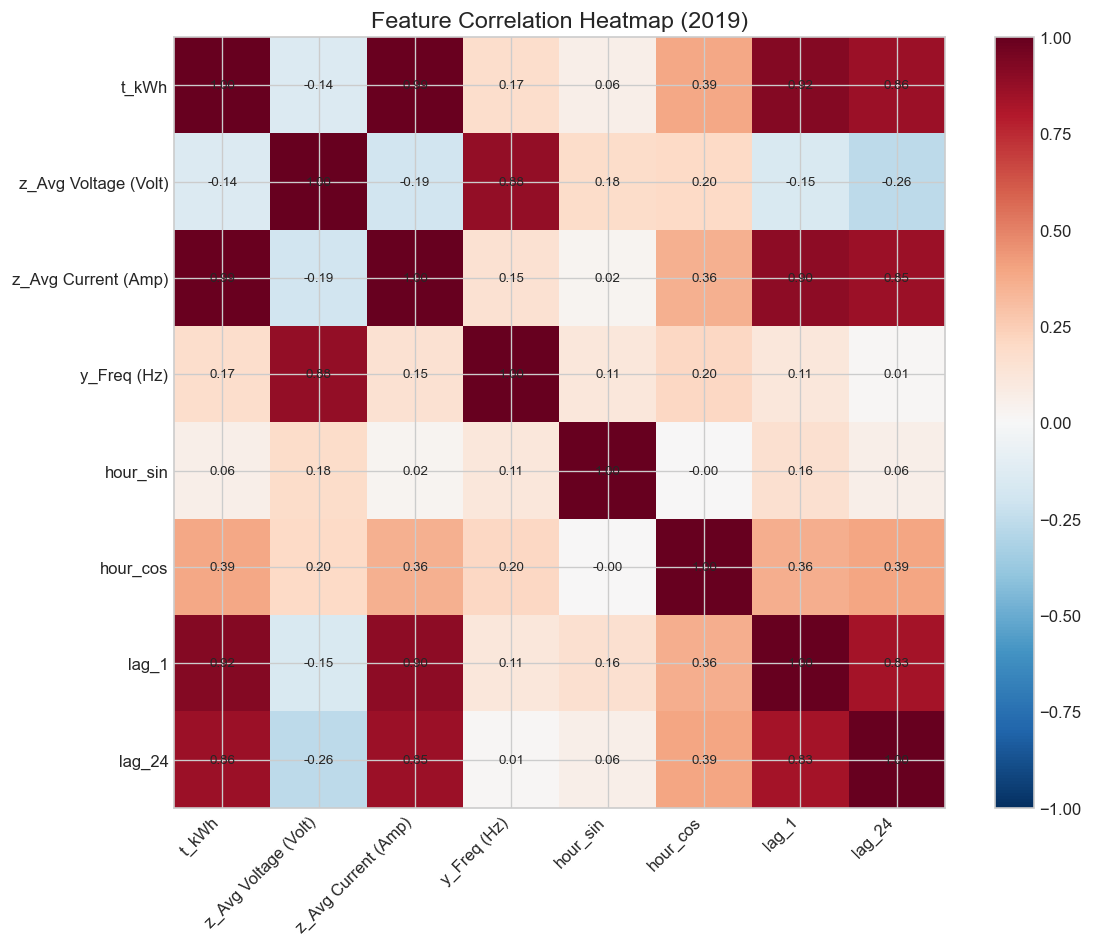

In [9]:
from src.feature_engineering import add_features

df_feat = add_features(df_2019.copy())

corr = df_feat.corr()

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha='right')
ax.set_yticklabels(corr.columns)

# Add correlation values
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center', fontsize=8)

plt.colorbar(im)
ax.set_title('Feature Correlation Heatmap (2019)', fontsize=14)
plt.tight_layout()
plt.show()

## 8. Missing Data Analysis

In [10]:
# Check raw data before preprocessing
raw_2019 = pd.read_csv(DATA_2019_PATH)
raw_2020 = pd.read_csv(DATA_2020_PATH)

print('=== Missing Values (2019) ===')
print(raw_2019.isnull().sum())
print(f'\nTotal: {raw_2019.isnull().sum().sum()} missing values out of {raw_2019.size} entries')
print(f'Missing %: {raw_2019.isnull().sum().sum() / raw_2019.size * 100:.2f}%')

print()
print('=== Missing Values (2020) ===')
print(raw_2020.isnull().sum())
print(f'\nTotal: {raw_2020.isnull().sum().sum()} missing values out of {raw_2020.size} entries')
print(f'Missing %: {raw_2020.isnull().sum().sum() / raw_2020.size * 100:.2f}%')

=== Missing Values (2019) ===
x_Timestamp             0
t_kWh                   0
z_Avg Voltage (Volt)    0
z_Avg Current (Amp)     0
y_Freq (Hz)             0
meter                   0
dtype: int64

Total: 0 missing values out of 6291450 entries
Missing %: 0.00%

=== Missing Values (2020) ===
x_Timestamp             0
t_kWh                   0
z_Avg Voltage (Volt)    0
z_Avg Current (Amp)     0
y_Freq (Hz)             0
meter                   0
dtype: int64

Total: 0 missing values out of 22556160 entries
Missing %: 0.00%


## Summary

Key findings from this EDA:

1. **Distribution shift**: The mean energy consumption differs between 2019 and 2020, validating the cold-start challenge
2. **Temporal patterns**: Clear hourly and monthly consumption patterns exist in both years
3. **Feature correlations**: Lag features show strong correlation with the target, justifying their inclusion
4. **Data quality**: Missing values are handled through interpolation after hourly resampling